## House Price Prediction - Eric Baah

In [2]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Lasso
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.utils import resample
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc
from ISLP import load_data
import warnings
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from ISLP.models import bs, ns
from ISLP.pygam import (approx_lam,degrees_of_freedom, plot as plot_gam, anova as anova_gam)
from sklearn.ensemble import \
(RandomForestRegressor as RF,
GradientBoostingRegressor as GBR)
from ISLP.bart import BART
from ISLP.models import (ModelSpec as MS, summarize, poly)
from sklearn.tree import (DecisionTreeClassifier as DTC,
DecisionTreeRegressor as DTR,
plot_tree,export_text)
import seaborn as sns
from xgboost import XGBRegressor as XGB
from lightgbm import LGBMRegressor as LGBMR
from pygam import (s as s_gam, l as l_gam, f as f_gam, LinearGAM, LogisticGAM)
from ISLP.transforms import (BSpline, NaturalSpline)
from ISLP.models import bs, ns
from ISLP.pygam import (approx_lam,degrees_of_freedom, plot as plot_gam, anova as anova_gam)
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Lasso
from statsmodels.stats.anova import anova_lm

## SUMMARY STATISTICS

In [3]:
# Load the dataset
data = pd.read_csv("train.csv") 

# Generate summary statistics

# Option 1: Use pandas to set float formatting (for the whole session)
pd.set_option('display.float_format', '{:.3f}'.format)

numeric_train = data.select_dtypes(include='number')

# Specify the statistics you want to include
summary_stats = numeric_train.drop(columns=['Id']).agg(['mean', 'std', 'min', 'max']).applymap(lambda x: round(x, 3))

sum_rounded  = summary_stats
# Transpose the summary statistics
transposed_summary = sum_rounded.T

# Export to LaTeX
latex_table = transposed_summary.to_latex()

print(latex_table)

# Optionally, you can export the LaTeX table directly to a file
transposed_summary.to_latex('summary_statistics_table1.tex')

# Read the file content
input_file = 'summary_statistics_table1.tex'
output_file = 'escaped_summary_statistics_table2.tex'

# Open the file, replace underscores, and save to a new file
with open(input_file, 'r') as file:
    content = file.read()

# Add a backslash before every underscore
modified_content = content.replace('_', r'\_')

# Write the modified content to a new file
with open(output_file, 'w') as file:
    file.write(modified_content)

print(f"Modified content has been saved to {output_file}")

\begin{tabular}{lrrrr}
\toprule
 & mean & std & min & max \\
\midrule
MSSubClass & 56.897000 & 42.301000 & 20.000000 & 190.000000 \\
LotFrontage & 70.050000 & 24.285000 & 21.000000 & 313.000000 \\
LotArea & 10516.828000 & 9981.265000 & 1300.000000 & 215245.000000 \\
OverallQual & 6.099000 & 1.383000 & 1.000000 & 10.000000 \\
OverallCond & 5.575000 & 1.113000 & 1.000000 & 9.000000 \\
YearBuilt & 1971.268000 & 30.203000 & 1872.000000 & 2010.000000 \\
YearRemodAdd & 1984.866000 & 20.645000 & 1950.000000 & 2010.000000 \\
MasVnrArea & 103.685000 & 181.066000 & 0.000000 & 1600.000000 \\
BsmtFinSF1 & 443.640000 & 456.098000 & 0.000000 & 5644.000000 \\
BsmtFinSF2 & 46.549000 & 161.319000 & 0.000000 & 1474.000000 \\
BsmtUnfSF & 567.240000 & 441.867000 & 0.000000 & 2336.000000 \\
TotalBsmtSF & 1057.429000 & 438.705000 & 0.000000 & 6110.000000 \\
1stFlrSF & 1162.627000 & 386.588000 & 334.000000 & 4692.000000 \\
2ndFlrSF & 346.992000 & 436.528000 & 0.000000 & 2065.000000 \\
LowQualFinSF & 5.845000

C:\Users\erick\AppData\Local\Temp\ipykernel_40236\314359113.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  summary_stats = numeric_train.drop(columns=['Id']).agg(['mean', 'std', 'min', 'max']).applymap(lambda x: round(x, 3))


## LINEAR MODELS

In [ ]:
# Load the dataset
data = pd.read_csv("train.csv")  

# Drop columns with NA values
data = data.dropna(axis=1)
data = data.drop('Id', axis=1)

print(data.shape)

# Creating Dummies from the qualitative predictors
data = pd.get_dummies(data, drop_first=True)

# Training features (X) and target (y)
from ISLP.models import (ModelSpec as MS, summarize, poly)
X = MS(data.drop(columns=['SalePrice'])).fit_transform(data)
y = data['SalePrice']  # Target variable

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8)

(1460, 61)


In [7]:
# OLS MODEL
OLS_Model=sm.OLS(y_train, X_train).fit()
print(OLS_Model.summary())

# Predict on the test set
OLS_pred = OLS_Model.predict(X_test)

# Calculate Test MSE
ols_test_mse = mean_squared_error(y_test, OLS_pred)
print(f'Test MSE for OLS: {ols_test_mse}')

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                     67.65
Date:                Wed, 04 Dec 2024   Prob (F-statistic):               0.00
Time:                        00:35:04   Log-Likelihood:                -13327.
No. Observations:                1168   AIC:                         2.703e+04
Df Residuals:                     982   BIC:                         2.797e+04
Df Model:                         185                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
intercept             -1.795e+

In [8]:
# GLM MODEL

# Fit a GLM with Gamma distribution and log link
gamma_model = sm.GLM(y_train, X_train, family=sm.families.Gamma(link=sm.families.links.log()))
gamma_results = gamma_model.fit()

print(gamma_results.summary())

# Make predictions
gamma_predictions = gamma_results.predict(X_test)

# Compute test error for Gamma model
gamma_mse = mean_squared_error(y_test, gamma_predictions)
gamma_mae = mean_absolute_error(y_test, gamma_predictions)

print(f"Test MSE for GLM: {gamma_mse:.4f}")

C:\Users\erick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


                 Generalized Linear Model Regression Results                  
Dep. Variable:              SalePrice   No. Observations:                 1168
Model:                            GLM   Df Residuals:                      982
Model Family:                   Gamma   Df Model:                          185
Link Function:                    log   Scale:                        0.010089
Method:                          IRLS   Log-Likelihood:                -12934.
Date:                Wed, 04 Dec 2024   Deviance:                       10.349
Time:                        00:35:11   Pearson chi2:                     9.91
No. Iterations:                    14   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
intercept                 1.14

In [9]:
# Publication tables
#!pip install stargazer

from stargazer.stargazer import Stargazer
stargazer = Stargazer([gamma_results])
latex_output = stargazer.render_latex()
print(stargazer.render_latex())

# Optionally, you can export the LaTeX table directly to a file
with open("regression_output.tex", "w") as file:
    file.write(latex_output)

# Read the file content
input_file = 'regression_output.tex'
output_file = 'regression_output_corrected.tex'

# Open the file, replace underscores, and save to a new file
with open(input_file, 'r') as file:
    content = file.read()

# Add a backslash before every underscore
modified_content = content.replace('_', r'\_')

# Write the modified content to a new file
with open(output_file, 'w') as file:
    file.write(modified_content)

print(f"Modified content has been saved to {output_file}")

\begin{table}[!htbp] \centering
\begin{tabular}{@{\extracolsep{5pt}}lc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{1}{c}{\textit{Dependent variable: SalePrice}} \
\cr \cline{2-2}
\\[-1.8ex] & (1) \\
\hline \\[-1.8ex]
 1stFlrSF & 0.000$^{***}$ \\
& (0.000) \\
 2ndFlrSF & 0.000$^{**}$ \\
& (0.000) \\
 3SsnPorch & 0.000$^{}$ \\
& (0.000) \\
 BedroomAbvGr & -0.002$^{}$ \\
& (0.007) \\
 BldgType_2fmCon & 0.043$^{}$ \\
& (0.058) \\
 BldgType_Duplex & -0.038$^{}$ \\
& (0.034) \\
 BldgType_Twnhs & -0.052$^{}$ \\
& (0.048) \\
 BldgType_TwnhsE & -0.018$^{}$ \\
& (0.043) \\
 BsmtFinSF1 & 0.000$^{***}$ \\
& (0.000) \\
 BsmtFinSF2 & 0.000$^{}$ \\
& (0.000) \\
 BsmtFullBath & 0.016$^{*}$ \\
& (0.010) \\
 BsmtHalfBath & -0.007$^{}$ \\
& (0.014) \\
 BsmtUnfSF & -0.000$^{}$ \\
& (0.000) \\
 CentralAir_Y & 0.052$^{***}$ \\
& (0.018) \\
 Condition1_Feedr & 0.006$^{}$ \\
& (0.025) \\
 Condition1_Norm & 0.051$^{**}$ \\
& (0.020) \\
 Condition1_PosA & 0.010$^{}$ \\
& (0.052) \\
 Condition1_PosN & 0.0

## TREE-BASED MODELS

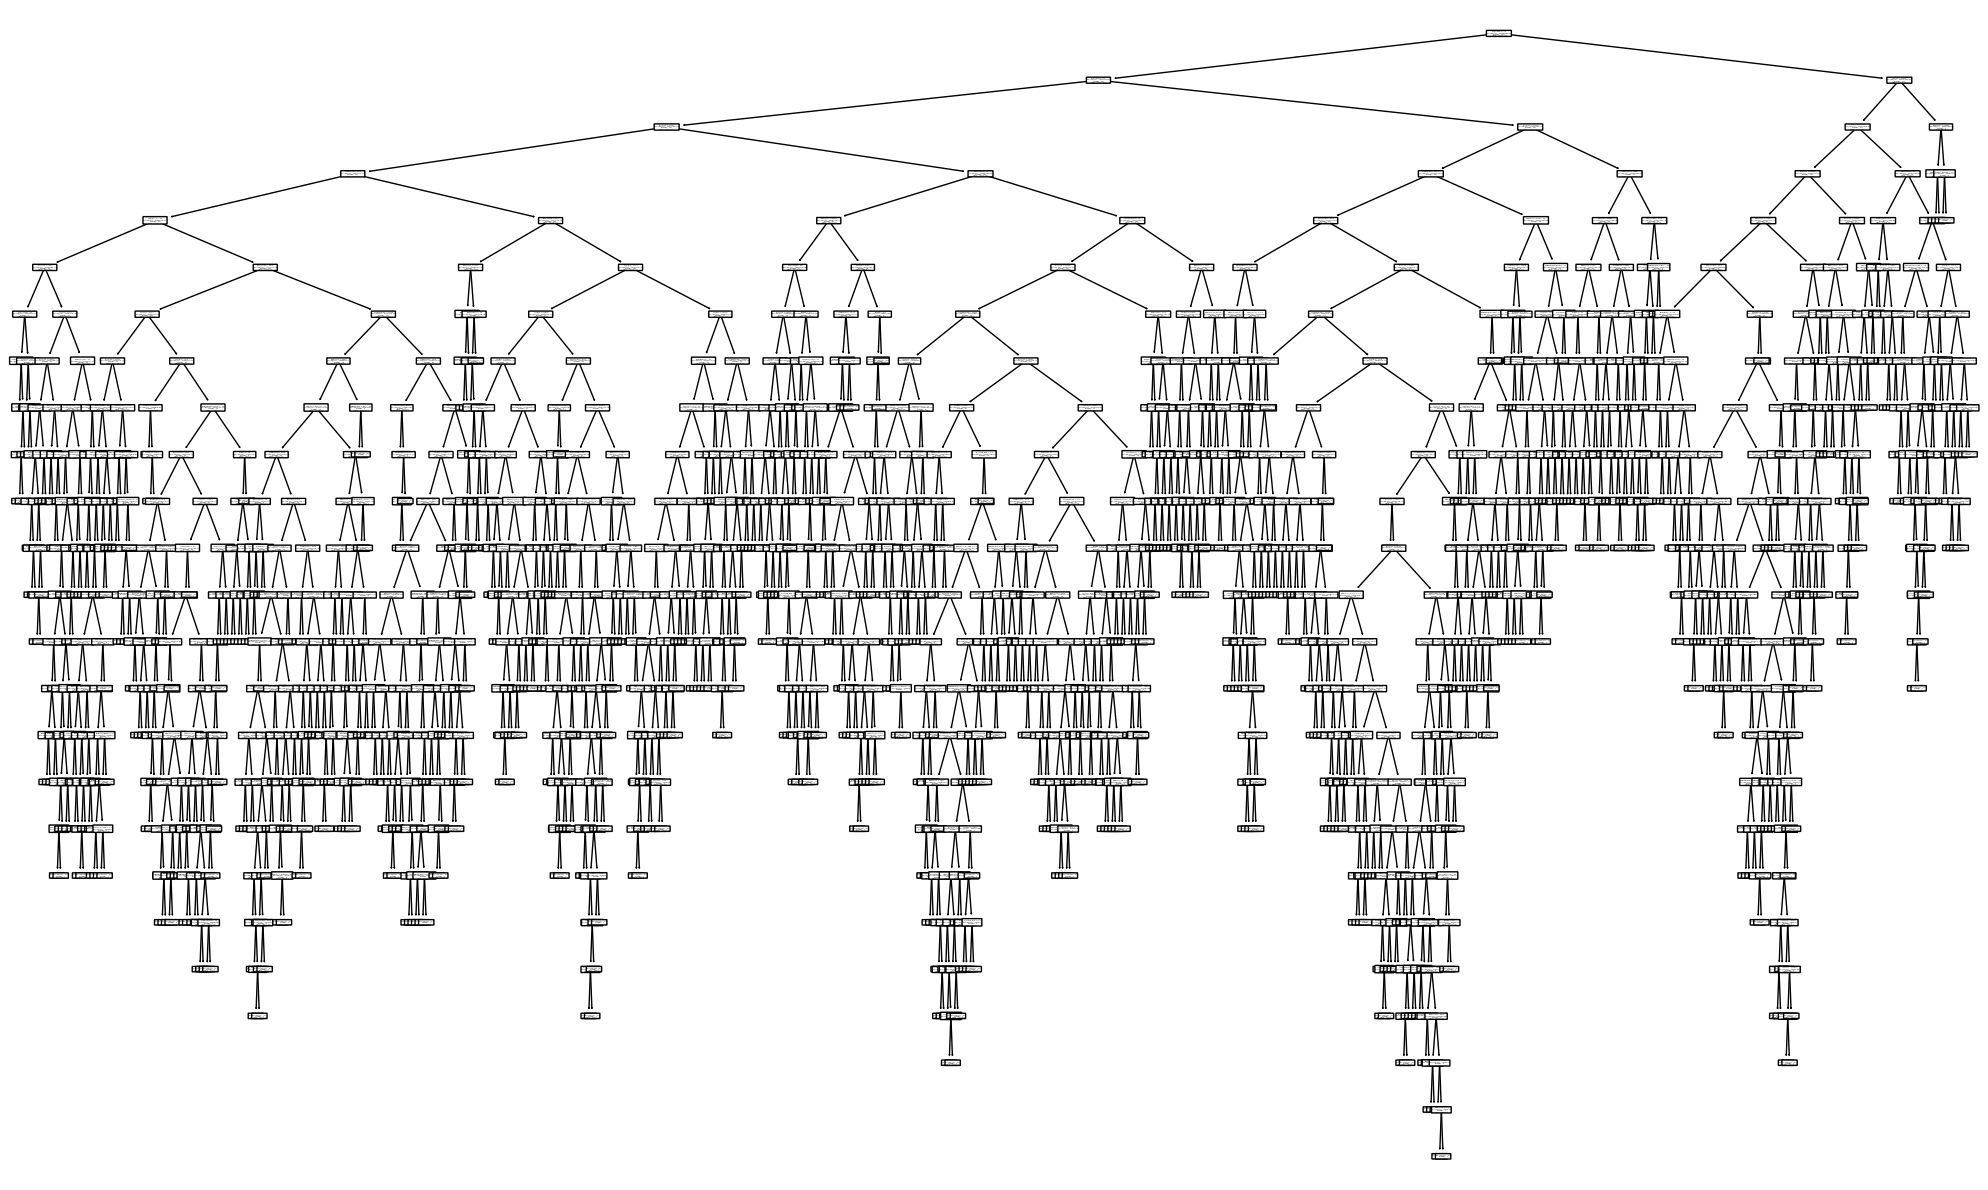

In [10]:
# SINGLE TREE

# Initialize and fit the regression tree model
reg_tree = DecisionTreeRegressor(random_state=42)
reg_tree.fit(X_train, y_train)

# Plot the regression tree
plt.figure(figsize=(20, 12))
plot_tree(reg_tree, feature_names=X.columns, rounded=True)
#plt.title('Decision Tree (Max Depth = 3)')
plt.tight_layout()
plt.savefig('Tree_Full.eps', format='eps')
plt.show()

# Predict on the test set and calculate the MSE
y_pred_tree = reg_tree.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)



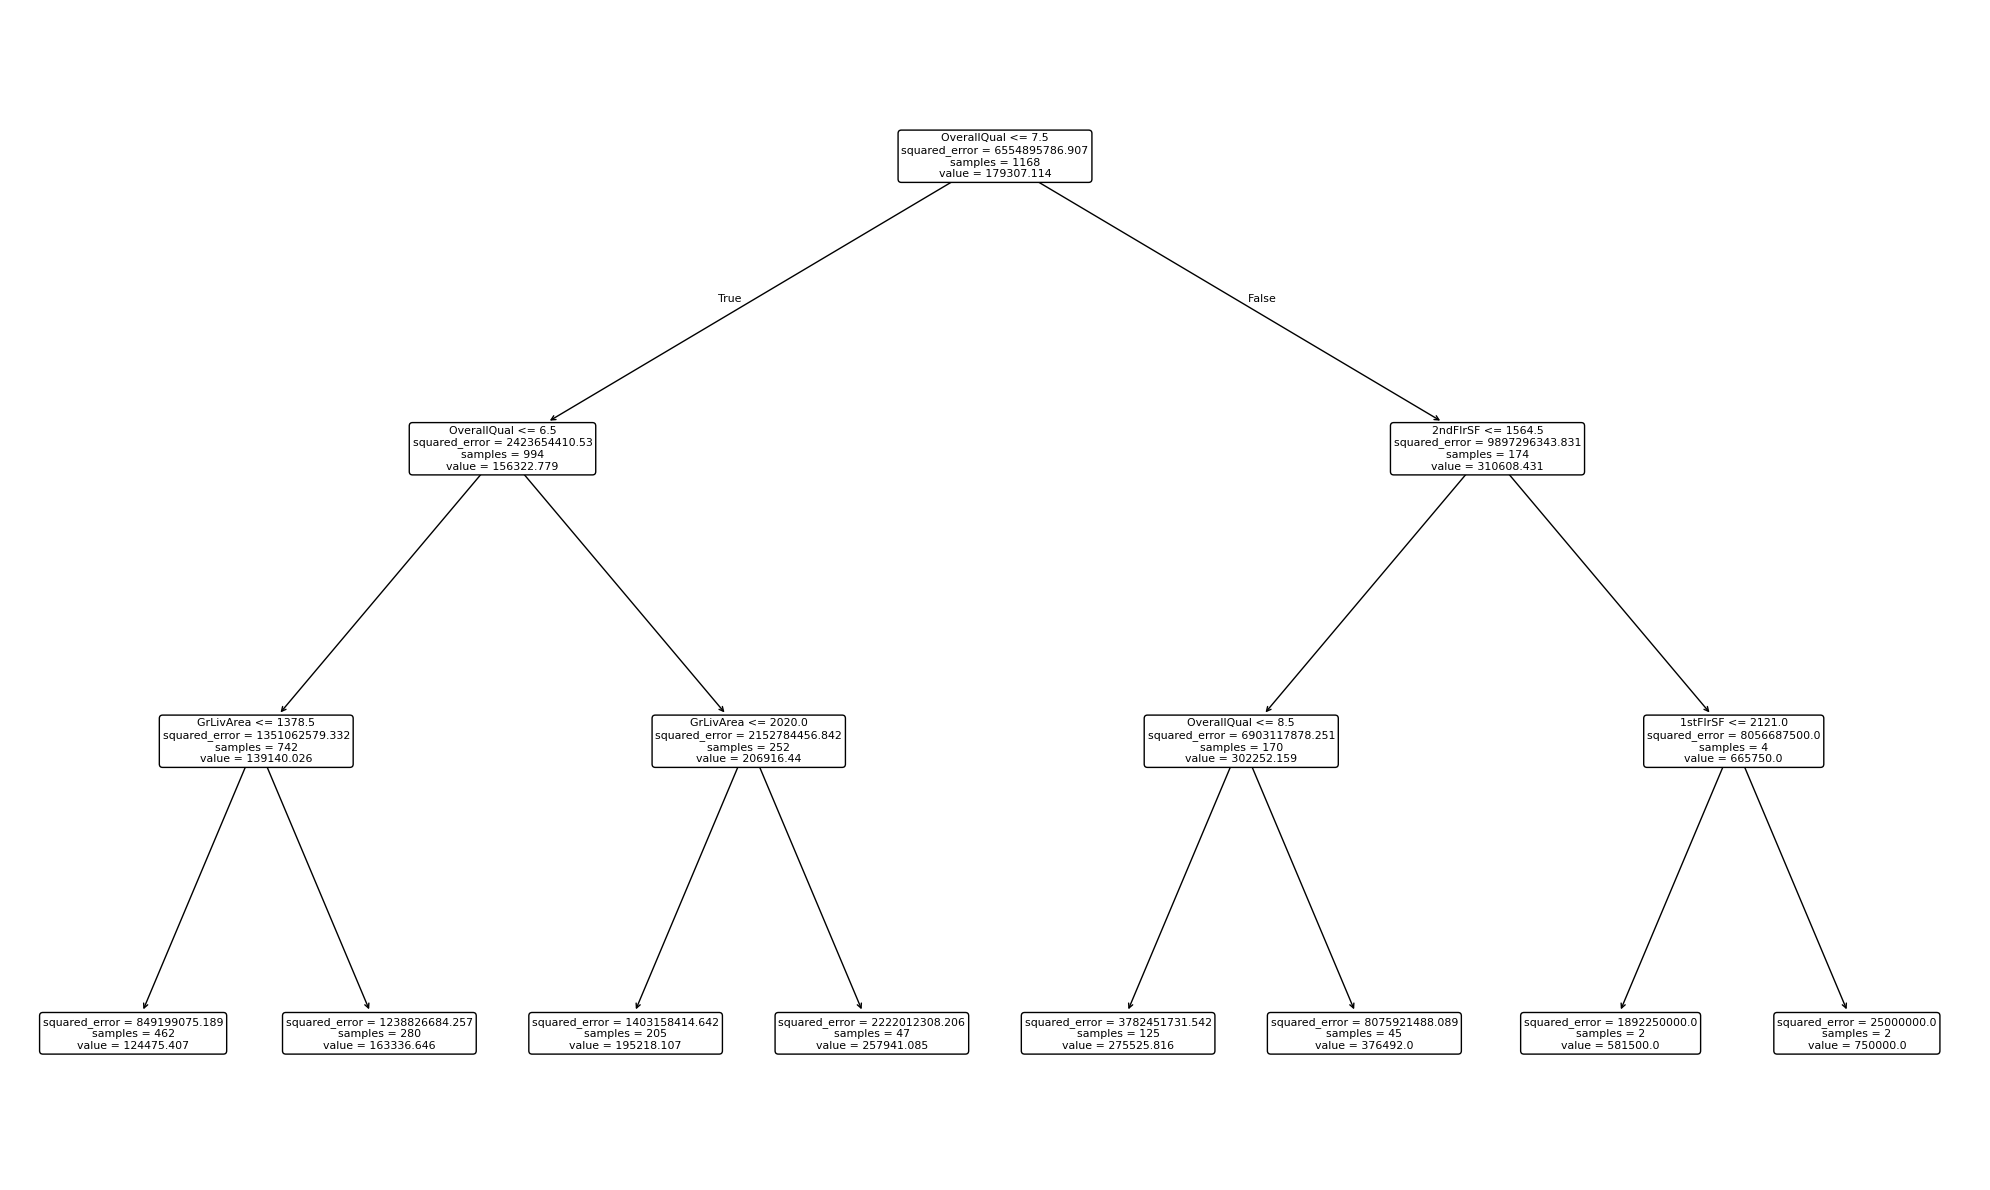

Test MSE for Regression Tree: 1651040862.408


In [106]:

# Initialize and fit the regression tree model
reg_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
reg_tree.fit(X_train, y_train)

# Plot the regression tree
plt.figure(figsize=(20, 12))
plot_tree(reg_tree, feature_names=X.columns, rounded=True)
#plt.title('Figure 1. Decision Tree (Max Depth = 3)', fontsize=20)
plt.tight_layout()
plt.savefig('Tree_truncated.eps', format='eps')
plt.show()

# Predict on the test set and calculate the MSE
y_pred_tree = reg_tree.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)

print(f"Test MSE for Regression Tree: {mse_tree:.3f}")


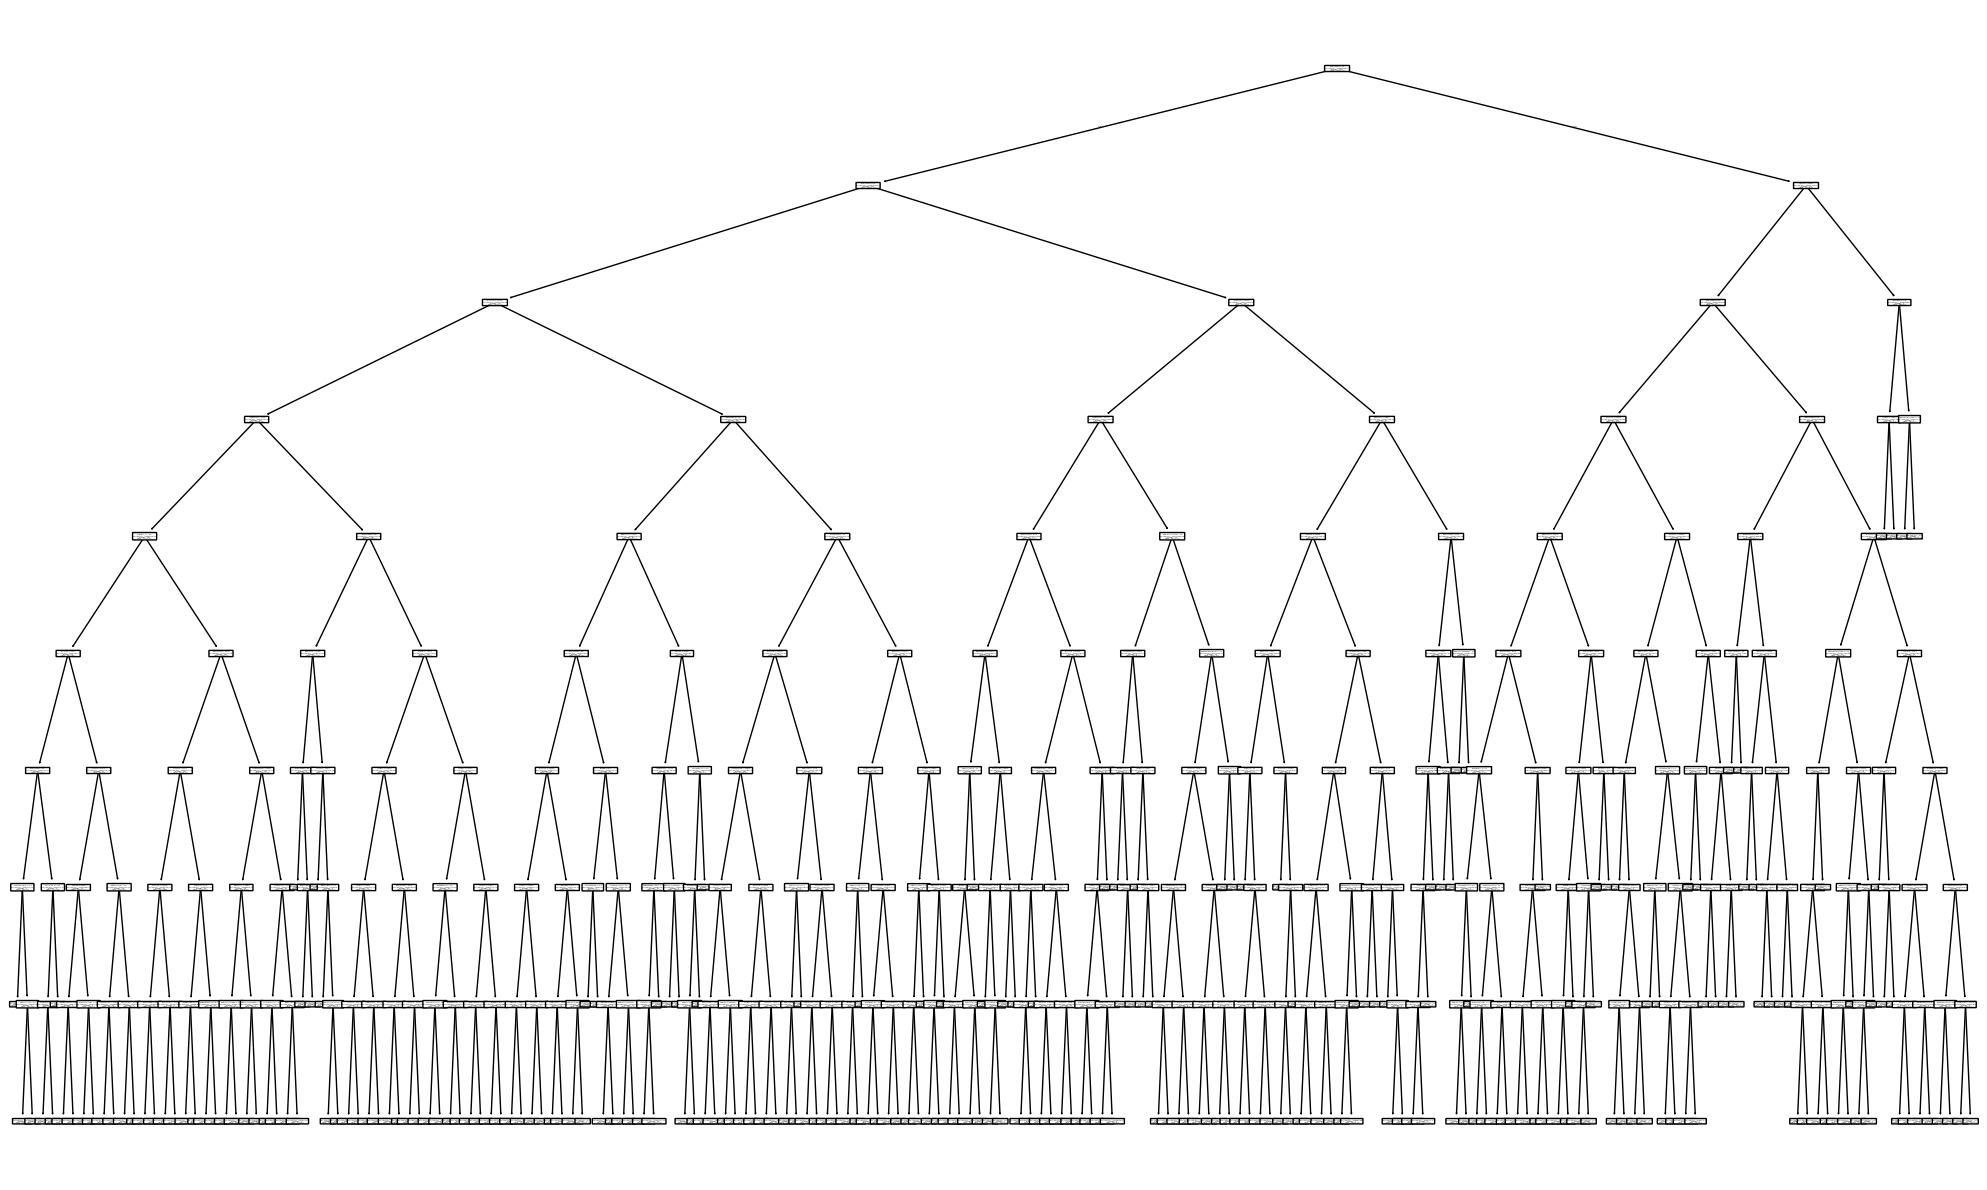

Optimal max_depth: 9
Test MSE for Pruned Regression Tree: 2059448737.675


In [107]:
# GRID SEARCH

from sklearn.model_selection import GridSearchCV

# Set up the parameter grid for max_depth (tree depth)
param_grid = {'max_depth': range(1, 20)}

# Use GridSearchCV to find the best max_depth
grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=10, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Get the best tree depth and fit a pruned tree
best_depth = grid_search.best_params_['max_depth']
pruned_tree = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
pruned_tree.fit(X_train, y_train)

# Plot the regression tree
plt.figure(figsize=(20, 12))
plot_tree(pruned_tree, feature_names=X.columns, rounded=True)
#plt.title('Figure 2. Decision Tree (Optimal Depth)', fontsize=20)
plt.tight_layout()
plt.savefig('Tree_opt.eps', format='eps')
plt.show()

# Predict on the test set and calculate MSE
y_pred_pruned = pruned_tree.predict(X_test)
mse_pruned = mean_squared_error(y_test, y_pred_pruned)

print(f"Optimal max_depth: {best_depth}")
print(f"Test MSE for Pruned Regression Tree: {mse_pruned:.3f}")

Test MSE for Bagging: 1170152884.750
                  Importance
OverallQual            0.579
GrLivArea              0.111
TotalBsmtSF            0.038
2ndFlrSF               0.031
1stFlrSF               0.030
...                      ...
Utilities_NoSeWa       0.000
RoofMatl_WdShake       0.000
Condition2_RRAn        0.000
Condition2_RRAe        0.000
intercept              0.000

[189 rows x 1 columns]


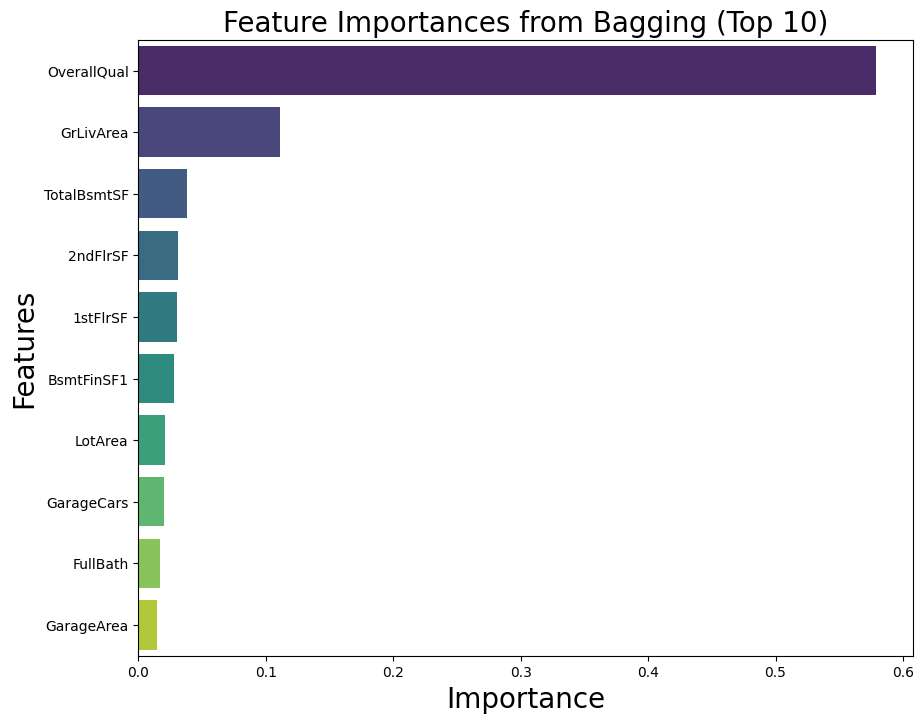

In [108]:
#BAGGING 

model = MS(data.columns.drop(['SalePrice']), intercept=True)
D = model.fit_transform(data)
feature_names = list(D.columns)
X = np.asarray(D)

# Initialize and fit a Bagging Regressor
bagging = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=42), n_estimators=100, random_state=42)
bagging.fit(X_train, y_train)

# Predict on the test set and calculate MSE
y_pred_bagging = bagging.predict(X_test)
mse_bagging = mean_squared_error(y_test, y_pred_bagging)

# Feature importance in bagging is usually derived from the base estimators
feature_importance_bagging = np.mean([
    tree.feature_importances_ for tree in bagging.estimators_
], axis=0)

print(f"Test MSE for Bagging: {mse_bagging:.3f}")
#print("Feature importances from Bagging:", feature_importance_bagging)

feature_imp = pd.DataFrame(
{'Importance':feature_importance_bagging},
index=feature_names)
print(feature_imp.sort_values(by='Importance', ascending=False))

# Sort by feature importance and select the top 10
top_10 = feature_imp.nlargest(10, 'Importance')

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y=top_10.index, data=top_10, palette='viridis')
plt.title('Feature Importances from Bagging (Top 10)', fontsize=20)
plt.xlabel('Importance', fontsize=20)
plt.ylabel('Features', fontsize=20)
plt.savefig('Bagging_feat_imp.eps', format='eps')
plt.show()



Test MSE for Random Forest: 1114393872.969
                    Importance
OverallQual              0.579
GrLivArea                0.111
TotalBsmtSF              0.039
2ndFlrSF                 0.032
1stFlrSF                 0.030
...                        ...
HeatingQC_Po             0.000
Exterior1st_CBlock       0.000
Condition2_RRAe          0.000
RoofMatl_Roll            0.000
intercept                0.000

[189 rows x 1 columns]


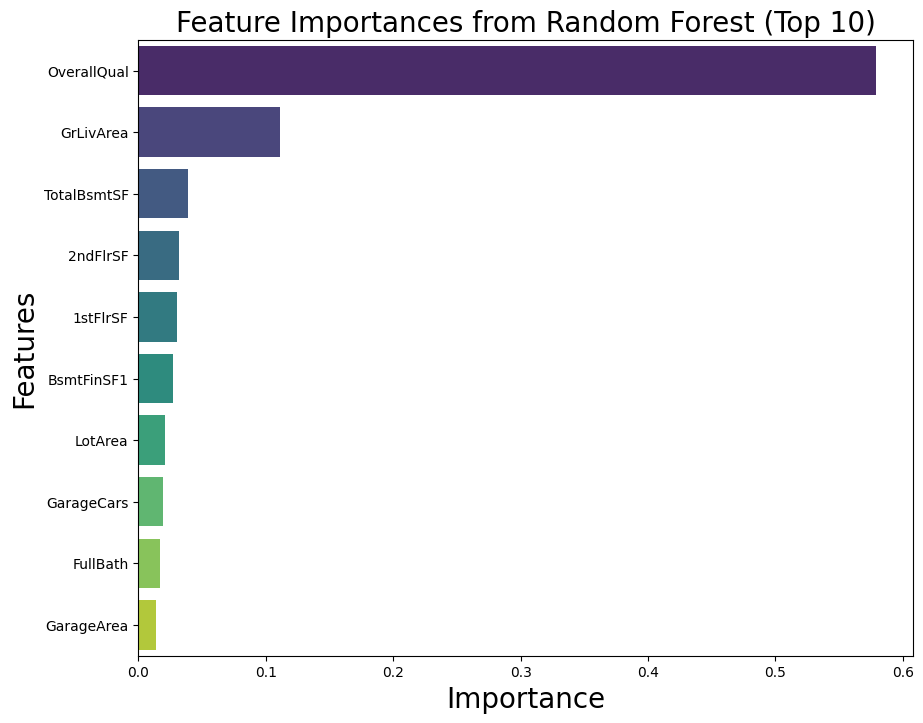

In [109]:
# RANDOM FOREST

# Initialize and fit a Random Forest Regressor
random_forest = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)

# Predict on the test set and calculate MSE
y_pred_rf = random_forest.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)

# Get feature importances
feature_importance_rf = random_forest.feature_importances_

print(f"Test MSE for Random Forest: {mse_rf:.3f}")
#print("Feature importances from Random Forest:", feature_importance_rf)

feature_imp = pd.DataFrame(
{'Importance':feature_importance_rf},
index=feature_names)
print(feature_imp.sort_values(by='Importance', ascending=False))

# Sort by feature importance and select the top 10
top_10 = feature_imp.nlargest(10, 'Importance')

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y= top_10.index, data=top_10, palette='viridis')
plt.title('Feature Importances from Random Forest (Top 10)', fontsize=20)
plt.xlabel('Importance', fontsize=20)
plt.ylabel('Features', fontsize=20)
plt.savefig('RF_feat_imp.eps', format='eps')
plt.show()


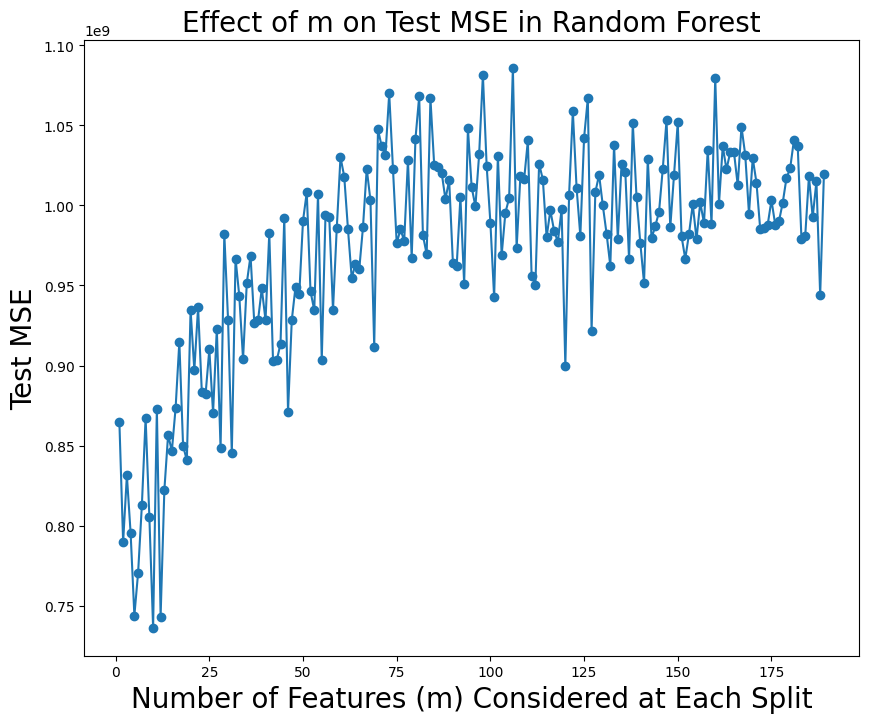

In [110]:
## List to store test MSE values for different m values
m_values = range(1, X_train.shape[1] + 1)  # m values from 1 to the number of features
test_mse_values = []

## Train a Random Forest with different max_features
for max_features in m_values:
    rf_model   = RandomForestRegressor(max_features=max_features, random_state=1, n_estimators=100)
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)
    test_mse = mean_squared_error(y_test, y_pred_rf)
    test_mse_values.append(test_mse)

## Plot the test MSE against m
plt.figure(figsize=(10, 8))
plt.plot(m_values, test_mse_values, marker='o', linestyle='-')
plt.xlabel('Number of Features (m) Considered at Each Split', fontsize=20)
plt.ylabel('Test MSE', fontsize=20)
plt.title('Effect of m on Test MSE in Random Forest', fontsize=20)
plt.savefig('RF_m_MSE.eps', format='eps')
plt.show()

In [111]:
# BOOSTING

warnings.filterwarnings('ignore')

# Gradient Boosting
gb = GBR(n_estimators=100, random_state=1)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
test_mse_gb = mean_squared_error(y_test, y_pred_gb)
print("Test MSE for Gradient Boosting:", test_mse_gb)

# XGBoost
xgb = XGB(n_estimators=100, random_state=1, eval_metric='rmse')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
test_mse_xgb = mean_squared_error(y_test, y_pred_xgb)
print("Test MSE for XGBoost:", test_mse_xgb)


# LightGBM
lgb = LGBMR(n_estimators=100, random_state=1, force_col_wise=True)
lgb.fit(X_train, y_train)
y_pred_lgb = lgb.predict(X_test)
test_mse_lgb = mean_squared_error(y_test, y_pred_lgb)
print("Test MSE for LightGBM:", test_mse_lgb)

# Best boosting approach
best_boosting_mse = min(test_mse_gb, test_mse_xgb, test_mse_lgb)
print("Best Boosting Test MSE:", best_boosting_mse)

Test MSE for Gradient Boosting: 994793928.2664747
Test MSE for XGBoost: 1107646740.3252983
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Total Bins 2737
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 117
[LightGBM] [Info] Start training from score 179307.113870
Test MSE for LightGBM: 1083696710.0096252
Best Boosting Test MSE: 994793928.2664747


## BAYESIAN ADDITIVE REGRESSION TREES (BART)

Test MSE for BART: 729837253.536


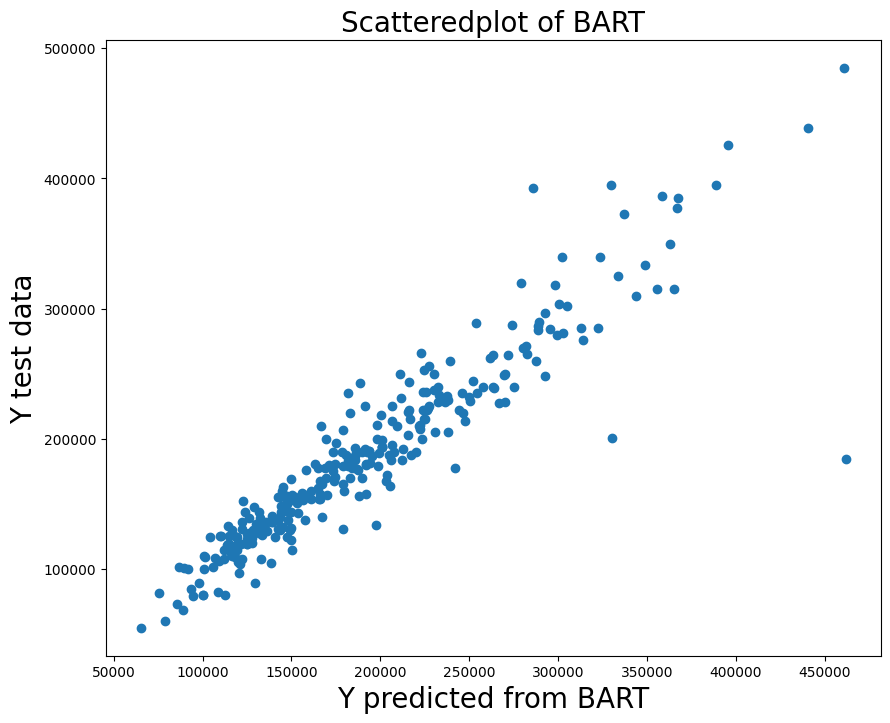

In [112]:
# BART

# Ensure numeric types and handle missing values
X_train_encoded = X_train.astype(float).fillna(X_train.mean())
y_train_encoded = y_train.astype(float)

# Train BART model
bart_model = BART(random_state=1, num_trees=100, burnin=100, ndraw=500)
bart_model.fit(X_train_encoded.to_numpy(), y_train_encoded.to_numpy())

# Predict and calculate Test MSE
y_pred_bart = bart_model.predict(X_test.to_numpy())
mse_bart = mean_squared_error(y_test, y_pred_bart)
print('Test MSE for BART: {}'.format(np.around(mse_bart, 3)))


ax = plt.subplots(figsize=(10,8))[1]
ax.scatter(y_pred_bart , y_test)
plt.xlabel('Y predicted from BART', fontsize=20)
plt.ylabel('Y test data', fontsize=20)
plt.title('Scatteredplot of BART', fontsize=20)
plt.savefig('BART_scatter.eps', format='eps')


## GENERALIZED ADDITIVE MODELS (GAM)

In [113]:
poly_rm = MS([poly('OverallQual', degree=4)]).fit(data)
M = sm.OLS(y, poly_rm.transform(data)).fit()
summarize(M)

,coef,std err,t,P>|t|
intercept,180900.000,1173.132,154.221,0.000
"poly(OverallQual, degree=4)[0]",2400000.000,44800.000,53.546,0.000
"poly(OverallQual, degree=4)[1]",697300.000,44800.000,15.555,0.000
"poly(OverallQual, degree=4)[2]",167600.000,44800.000,3.738,0.000
"poly(OverallQual, degree=4)[3]",-95790.000,44800.000,-2.137,0.033


In [114]:
#  see the fitting
rm=data['OverallQual']
rm_grid = np.linspace(rm.min(), rm.max(), 100)
rm_df = pd.DataFrame({'OverallQual': rm_grid})

In [115]:
#define a general plot function
def plot_rm_fit(rm_df, basis_list, titles):
    # Create the figure and axes
    fig, ax = plt.subplots(figsize=(10, 8))

    # Scatter plot of the original data
    ax.scatter(rm, y, facecolor='gray', alpha=0.5, label='Data')

    # Loop through each basis and title to plot each fit
    for basis, title, color in zip(basis_list, titles, ['b', 'g']):
        X = basis.transform(data)
        Xnew = basis.transform(rm_df)
        M = sm.OLS(y, X).fit()
        preds = M.get_prediction(Xnew)
        bands = preds.conf_int(alpha=0.05)

        # Plot the predicted mean and confidence bands
        ax.plot(rm_df.values, preds.predicted_mean, color=color, label=title, linewidth=3)
        ax.plot(rm_df.values, bands[:, 0], f'{color}--', linewidth=1, alpha=0.6)
        ax.plot(rm_df.values, bands[:, 1], f'{color}--', linewidth=1, alpha=0.6)

    # Set title and labels
    ax.set_title('Comparison of Fits', fontsize=20)
    ax.set_xlabel('Overall Quality', fontsize=20)
    ax.set_ylabel('Sale Price', fontsize=20)
    ax.legend(fontsize=15)

    return ax


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


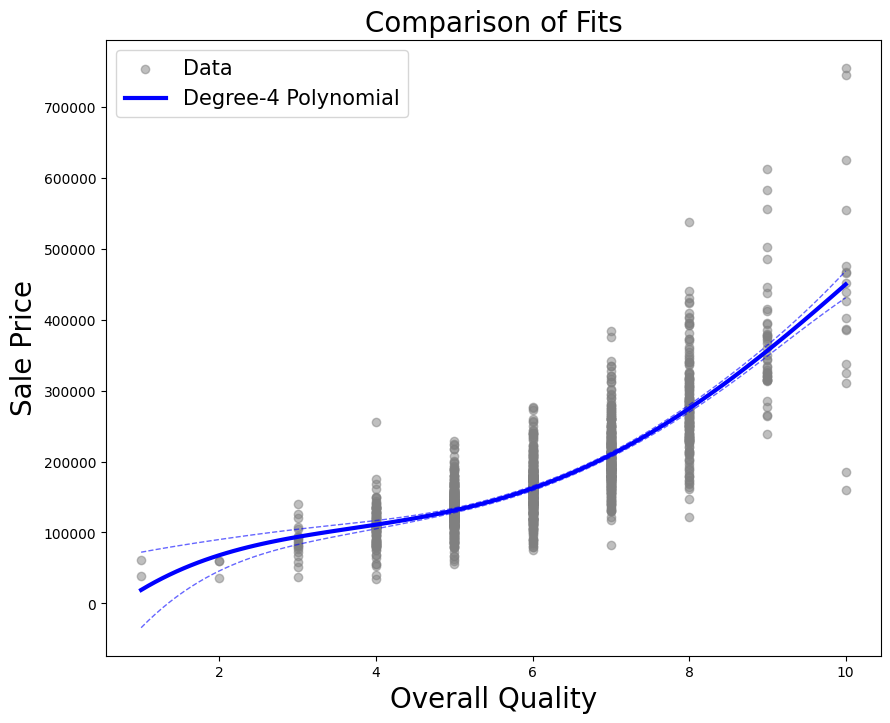

In [116]:
basis_list = [poly_rm]
titles=['Degree-4 Polynomial']
plot_rm_fit(rm_df, basis_list, titles)
plt.savefig('GAM_1.eps', format='eps')
plt.show()


In [117]:
##anova approach to determine the order
models = [MS([poly('OverallQual', degree=d)])
for d in range(1, 6)]
Xs = [model.fit_transform(data) for model in models]
anova_lm(*[sm.OLS(y, X_).fit() for X_ in Xs])

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1458.000,3446964182487.858,0.000,NaN,NaN,NaN
1,1457.000,2960797117475.939,1.000,486167065011.919,242.906,0.000
2,1456.000,2932719032266.990,1.000,28078085208.949,14.029,0.000
3,1455.000,2923542849658.779,1.000,9176182608.211,4.585,0.032
4,1454.000,2910125586306.455,1.000,13417263352.324,6.704,0.010


In [118]:
####different rm groups####
cut_rm = pd.qcut(rm , 4)
summarize(sm.OLS(y, pd.get_dummies(cut_rm)).fit())

,coef,std err,t,P>|t|
"(0.999, 5.0]",125600.000,2163.675,58.065,0.000
"(5.0, 6.0]",161600.000,2595.059,62.273,0.000
"(6.0, 7.0]",207700.000,2809.880,73.924,0.000
"(7.0, 10.0]",305000.000,3316.388,91.978,0.000


In [119]:
#####cubic spline ######
bs_rm = MS([bs('OverallQual', internal_knots=[4,6,7])])
Xbs = bs_rm.fit_transform(data)
M = sm.OLS(y, Xbs).fit()
summarize(M)


,coef,std err,t,P>|t|
intercept,47050.000,30500.000,1.544,0.123
"bs(OverallQual, internal_knots=[4, 6, 7])[0]",8277.830,43500.000,0.190,0.849
"bs(OverallQual, internal_knots=[4, 6, 7])[1]",57780.000,30900.000,1.870,0.062
"bs(OverallQual, internal_knots=[4, 6, 7])[2]",99060.000,31300.000,3.167,0.002
"bs(OverallQual, internal_knots=[4, 6, 7])[3]",181700.000,30900.000,5.888,0.000
"bs(OverallQual, internal_knots=[4, 6, 7])[4]",323200.000,33000.000,9.788,0.000
"bs(OverallQual, internal_knots=[4, 6, 7])[5]",394700.000,32100.000,12.306,0.000


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


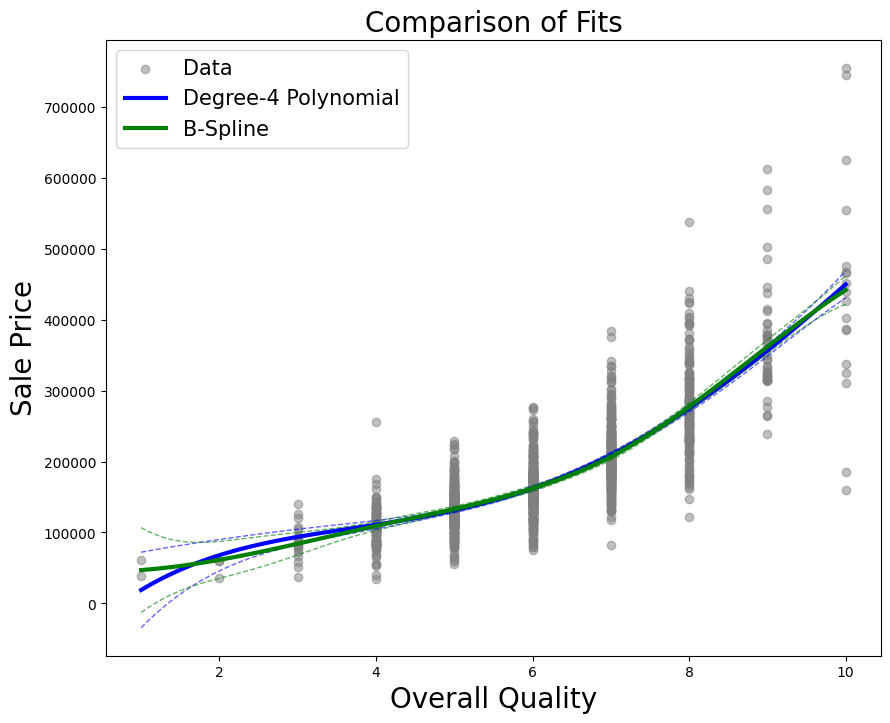

In [120]:
basis_list = [poly_rm, bs_rm]
titles = ['Degree-4 Polynomial', 'B-Spline']

# Plot both curves on the same plot
plot_rm_fit(rm_df, basis_list, titles)
plt.savefig('GAM_2.eps', format='eps')
plt.show()

In [121]:
###specify degree of freedom###
bs_rm0 = MS([bs('OverallQual', df=3, degree=2)]).fit(data)
Xbs0 = bs_rm0.transform(data)
summarize(sm.OLS(y, Xbs0).fit())

,coef,std err,t,P>|t|
intercept,62820.000,18400.000,3.412,0.001
"bs(OverallQual, df=3, degree=2)[0]",14940.000,22000.000,0.680,0.497
"bs(OverallQual, df=3, degree=2)[1]",170300.000,17100.000,9.951,0.000
"bs(OverallQual, df=3, degree=2)[2]",396200.000,21200.000,18.673,0.000


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


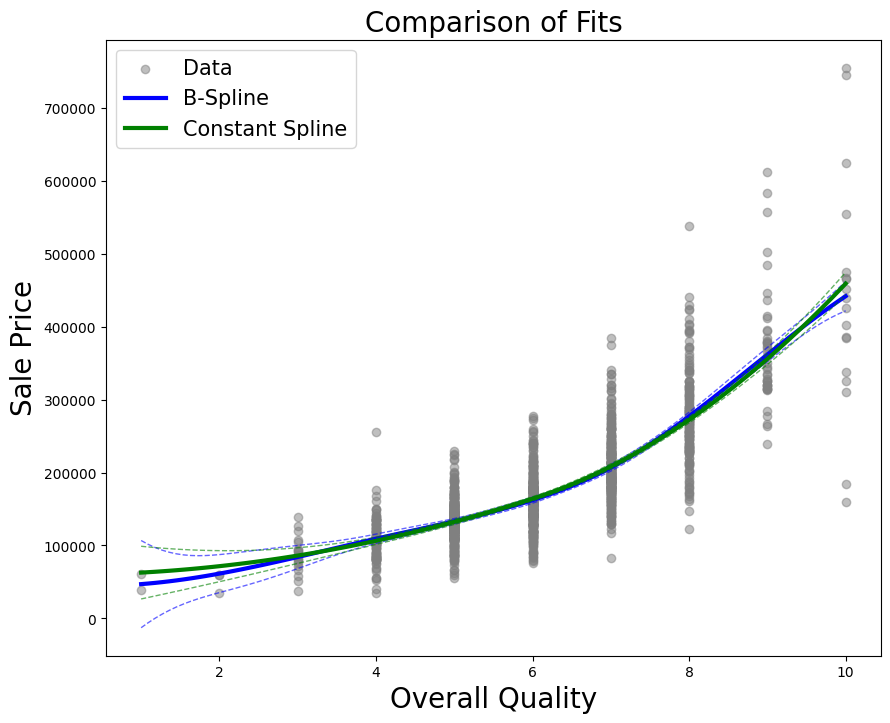

In [122]:
basis_list = [bs_rm, bs_rm0]
titles = ['B-Spline', 'Constant Spline']

# Plot both curves on the same plot
plot_rm_fit(rm_df, basis_list, titles)
plt.savefig('GAM_3.eps', format='eps')
plt.show()

In [123]:
####NaturalSpline###
ns_rm = MS([ns('OverallQual', df=5)]).fit(data)
M_ns = sm.OLS(y, ns_rm.transform(data)).fit()
summarize(M_ns)

,coef,std err,t,P>|t|
intercept,44330.000,21800.000,2.035,0.042
"ns(OverallQual, df=5)[0]",107700.000,19600.000,5.494,0.000
"ns(OverallQual, df=5)[1]",126700.000,24600.000,5.142,0.000
"ns(OverallQual, df=5)[2]",170200.000,12200.000,13.911,0.000
"ns(OverallQual, df=5)[3]",366800.000,48400.000,7.582,0.000
"ns(OverallQual, df=5)[4]",372400.000,11900.000,31.411,0.000


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


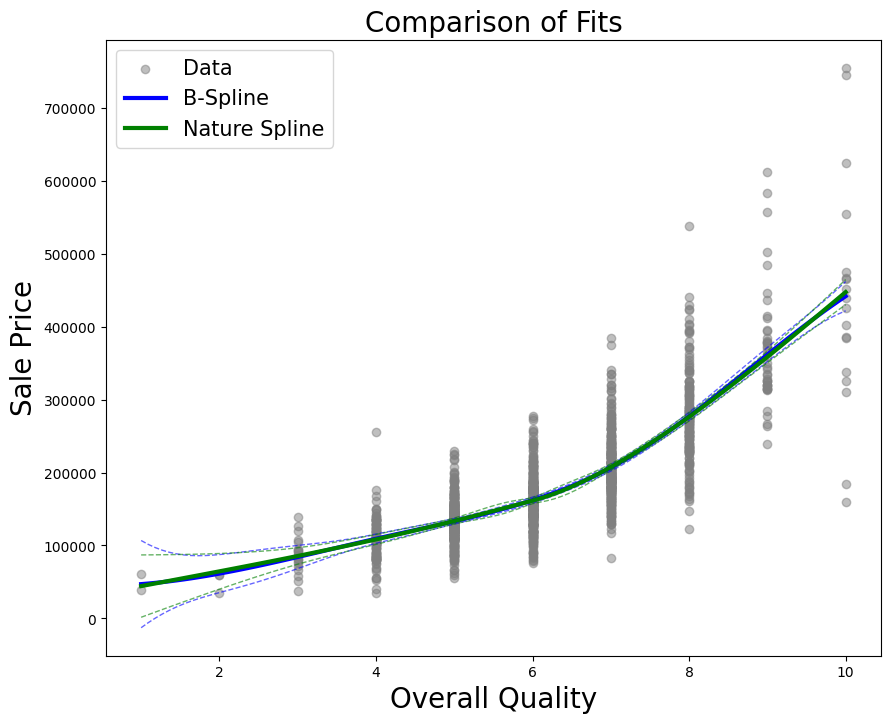

In [124]:
basis_list = [bs_rm, ns_rm]
titles = ['B-Spline', 'Nature Spline']

# Plot both curves on the same plot
plot_rm_fit(rm_df, basis_list, titles)
plt.savefig('GAM_4.eps', format='eps')
plt.show()

In [125]:
X_rm = np.asarray(rm).reshape((-1,1))
gam = LinearGAM(s_gam(0, lam=3.98)).fit(X_rm, y)
gam_opt = gam.gridsearch(X_rm , y)
best_lambda = gam_opt.lam
print(f"Best lambda: {best_lambda}")

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:00
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


Best lambda: [[251.18864315095772]]


In [126]:
# Define a modified plot function to include the smoothing spline fit
def plot_rm_fit_extended(rm_df, basis_list, titles, colors):
    fig, ax = plt.subplots(figsize=(10, 8))

    # Scatter plot of the original data
    ax.scatter(rm, y, facecolor='gray', alpha=0.5, label='Original Data')

    # Loop through each basis, title, and color to plot each fit
    for basis, title, color in zip(basis_list, titles, colors):
        if isinstance(basis, LinearGAM):
            # For smoothing spline fit
            y_pred = basis.predict(rm_df.values.reshape(-1, 1))
            ax.plot(rm_df.values, y_pred, color=color, label=title, linewidth=3)
        else:
            # For B-spline and natural spline fits
            X_new = basis.transform(data)
            M = sm.OLS(y, X_new).fit()
            preds = M.get_prediction(basis.transform(rm_df))
            bands = preds.conf_int(alpha=0.05)

            ax.plot(rm_df.values, preds.predicted_mean, color=color, label=title, linewidth=3)
            ax.plot(rm_df.values, bands[:, 0], f'{color}--', linewidth=1, alpha=0.6)
            ax.plot(rm_df.values, bands[:, 1], f'{color}--', linewidth=1, alpha=0.6)

    # Set title and labels
    ax.set_title('Comparison of Spline Fits', fontsize=20)
    ax.set_xlabel('Overall Quality', fontsize=20)
    ax.set_ylabel('Sale Price', fontsize=20)
    ax.legend(fontsize=15)

    return ax

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


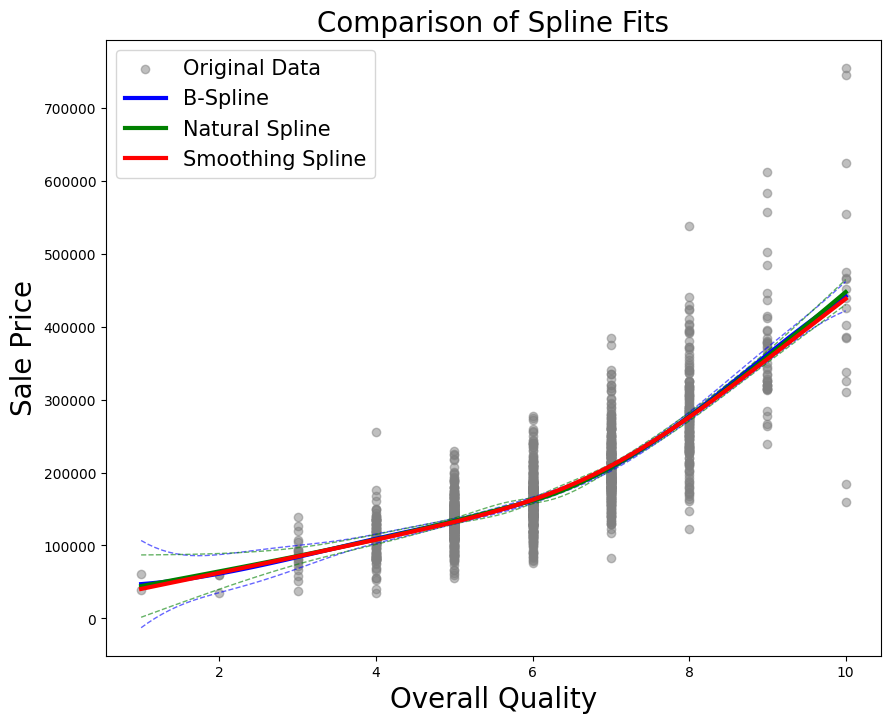

In [127]:
# Plot all spline fits on the same plot
basis_list = [bs_rm, ns_rm, gam]
titles = ['B-Spline', 'Natural Spline', 'Smoothing Spline']
colors = ['b', 'g', 'r']

rm_df = pd.DataFrame({'OverallQual': np.linspace(rm.min(), rm.max(), 100)})
plot_rm_fit_extended(rm_df, basis_list, titles, colors)
plt.savefig('GAM_5.eps', format='eps')
plt.show()

In [128]:
#####GAM model###
# Prepare variables and basis functions for the GAM model
gam = LinearGAM(
    s_gam(0, lam=0.6) +  # Smoothing spline for the first feature ('crim')
    s_gam(1, lam=0.6) +  # Smoothing spline for the second feature ('zn')
    l_gam(2) +           # Linear term for the third feature ('indus')
    f_gam(3) +           # Linear term for the fourth feature (factor 'chas')
    s_gam(4) +           # Smoothing spline for 'nox'
    l_gam(5) +           # Linear term for 'rm'
    s_gam(6) +           # Smoothing spline for 'age'
    l_gam(7) +           # Linear term for 'dis'
    s_gam(8, lam=0.6) +  # Smoothing spline for 'rad'
    l_gam(9) +           # Linear term for 'tax'
    s_gam(10) +          # Smoothing spline for 'ptratio'
    s_gam(11, lam=0.6)   # Smoothing spline for 'lstat'
)

# Fit the model on the training data
gam.fit(X_train, y_train)

# Summarize the model fit
gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     64.2002
Link Function:                     IdentityLink Log Likelihood:                                -25011.5114
Number of Samples:                         1168 AIC:                                            50153.4232
                                                AICc:                                           50161.2581
                                                GCV:                                        882828158.5998
                                                Scale:                                      795933895.9441
                                                Pseudo R-Squared:                                   0.8852
Feature Function                  Lam

In [129]:
# Predict on the test set
y_pred = gam.predict(X_test)

# Calculate mean squared error on test set
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.4f}")

Test MSE: 1513036678.4868


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


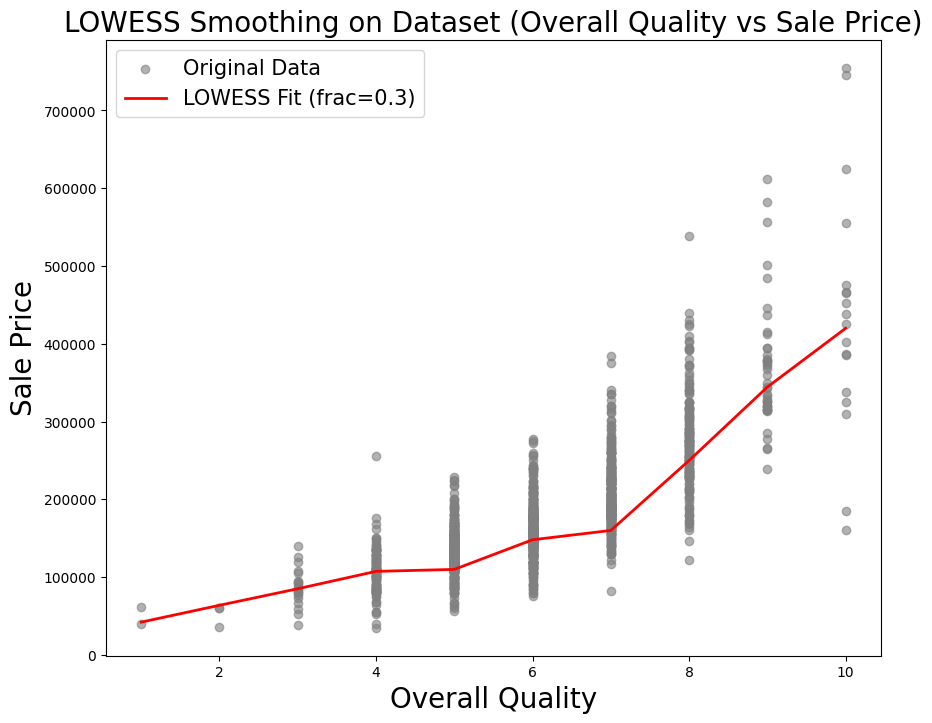

In [130]:
# Apply LOWESS smoothing
lowess_fit = sm.nonparametric.lowess(y, rm, frac=0.1)

# Extract the smoothed x and y values
rm_smoothed = lowess_fit[:, 0]
medv_smoothed = lowess_fit[:, 1]

# Plot the original data and the LOWESS fit
plt.figure(figsize=(10, 8))
plt.scatter(rm, y, facecolor='gray', alpha=0.6, label='Original Data')
plt.plot(rm_smoothed, medv_smoothed, color='r', label='LOWESS Fit (frac=0.3)', linewidth=2)
plt.xlabel('Overall Quality', fontsize=20)
plt.ylabel('Sale Price', fontsize=20)
plt.title('LOWESS Smoothing on Dataset (Overall Quality vs Sale Price)', fontsize=20)
plt.legend(fontsize=15)
plt.savefig('GAM_6.eps', format='eps')
plt.show()

## MODEL COMPARISON

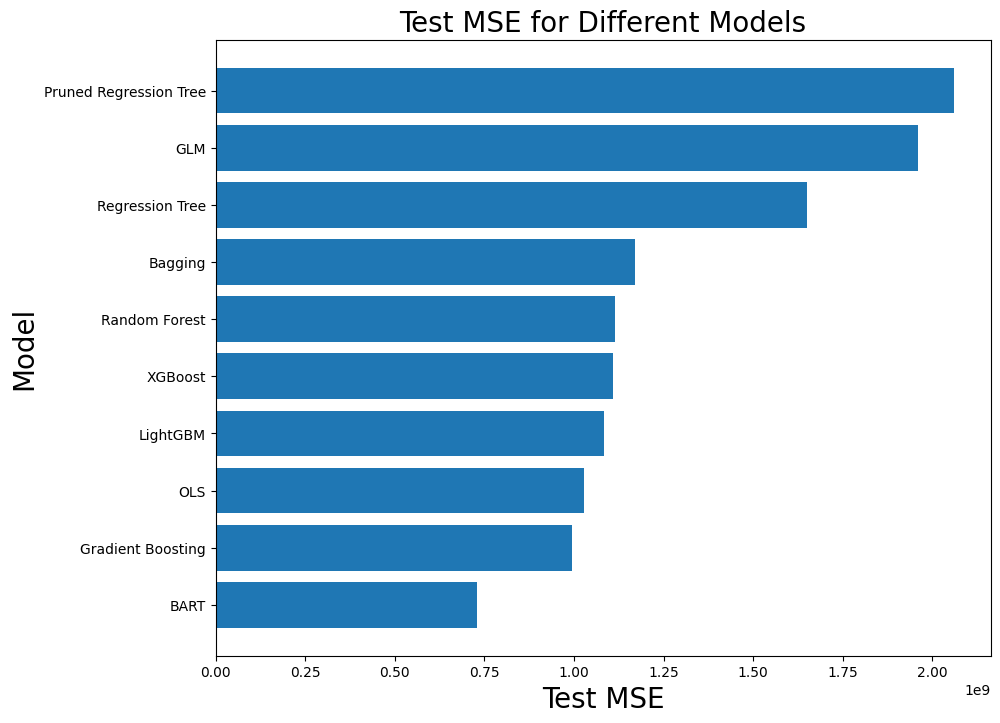

In [131]:
# Data
models = [
    "OLS", "GLM", "Regression Tree", "Pruned Regression Tree", "Bagging",
    "Random Forest", "Gradient Boosting", "XGBoost", "LightGBM", "BART"
]
mse = [
    1027833125.33, 1960774876.66, 1651040862.41, 2059448737.68, 1170152884.75,
    1114393872.97, 994793928.27, 1107646740.33, 1083696710.01, 729837253.54
]

# Create DataFrame for sorting
df = pd.DataFrame({"Model": models, "Test MSE": mse}).sort_values(by="Test MSE", ascending=False)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(df["Model"], df["Test MSE"])
plt.xlabel("Test MSE", fontsize=20)
plt.ylabel("Model", fontsize=20)
plt.title("Test MSE for Different Models", fontsize=20)
plt.gca().invert_yaxis()  # Reverse order for highest MSE at the top
plt.savefig('Model_Comp.eps', format='eps')
plt.show()
